# DAMO 510-8 Predictive Analytics – Final Project
## World Bank GDP Indicators Analysis

---
### Group Members
1. Roshan Basnet
2. Sayema Islam
3. Christhian Martinez

---
### CRISP-DM Phases Covered
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling (Regression + Classification + Time Series)
5. Evaluation
6. Deployment / Reflection

---
## PHASE 1 – Business Understanding

### Problem Definition
GDP growth is one of the most important indicators of a country's economic health. Governments, investors, and policymakers rely on GDP trends to make critical decisions. However, predicting economic outcomes is complex due to interactions between indicators like trade, inflation, investment, and savings.

### Objectives
1. **Regression**: Predict a country's GDP per capita using other macroeconomic indicators.
2. **Classification**: Classify countries into income tiers (Low, Middle, High) based on their economic profile.
3. **Time Series**: Forecast GDP growth rate for selected countries over time.

### Success Criteria
- Regression R² > 0.75
- Classification Accuracy > 80%
- Time Series RMSE as low as possible with meaningful forecast trends

---
## PHASE 2 – Data Understanding

### Dataset Description
- **Source**: World Bank Open Data Portal (https://data.worldbank.org)
- **Rows**: 2,665 | **Columns**: 24
- **Coverage**: 268 countries/territories, years 2006–2025
- **Structure**: Long format — each row = one country + one indicator

### Features (Series Names)
| Indicator | Code |
|-----------|------|
| Current account balance (% of GDP) | BN.CAB.XOKA.GD.ZS |
| Government expenditure on education (% of GDP) | SE.XPD.TOTL.GD.ZS |
| Gross domestic savings (% of GDP) | NY.GDS.TOTL.ZS |
| Tax revenue (% of GDP) | GC.TAX.TOTL.GD.ZS |
| Foreign direct investment, net inflows (% of GDP) | BX.KLT.DINV.WD.GD.ZS |
| Trade (% of GDP) | NE.TRD.GNFS.ZS |
| Gross capital formation (% of GDP) | NE.GDI.TOTL.ZS |
| Inflation, GDP deflator (annual %) | NY.GDP.DEFL.KD.ZG |
| GDP per capita (current US$) | NY.GDP.PCAP.CD |
| GDP growth (annual %) | NY.GDP.MKTP.KD.ZG |

In [1]:
# ── STEP 1: Install & Import Libraries ──────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Time Series
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# ── STEP 2: Load the Raw Dataset ─────────────────────────────────────────────
df_raw = pd.read_csv('GDP.csv')

print("Shape:", df_raw.shape)
print("\nColumn Names:")
print(df_raw.columns.tolist())
print("\nFirst 5 rows:")
df_raw.head()

Shape: (2665, 24)

Column Names:
['Country Name', 'Country Code', 'Series Name', 'Series Code', '2006 [YR2006]', '2007 [YR2007]', '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]', '2025 [YR2025]']

First 5 rows:


,Country Name,Country Code,Series Name,Series Code,2006 [YR2006],2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],...,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Afghanistan,AFG,Current account balance (% of GDP),BN.CAB.XOKA.GD.ZS,..,..,-2.35799044700136,2.23601941932175,-3.64331388234628,-12.6195382087159,...,-14.9501951919169,-18.9559612272258,-21.5852741164653,-20.1704643881064,-15.7183027911684,..,..,..,..,..
1,Afghanistan,AFG,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GD.ZS,..,..,..,..,3.4794499874115,3.4620099067688,...,4.54397010803223,4.34319019317627,..,..,..,..,..,..,..,..
2,Afghanistan,AFG,Gross domestic savings (% of GDP),NY.GDS.TOTL.ZS,..,..,..,..,..,..,...,..,..,..,..,-14.4125667930104,-9.74070711301084,-19.456991010884,-19.2855186503912,..,..
3,Afghanistan,AFG,Tax revenue (% of GDP),GC.TAX.TOTL.GD.ZS,6.96759757536323,5.28345660361407,6.08796493104171,8.48175836115538,9.16975191897818,8.91679399623322,...,9.50265278008681,9.8984508955205,..,..,..,..,..,..,..,..
4,Afghanistan,AFG,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,3.41377297323201,1.93570171391636,0.45536044478174,0.45188914562189,1.20311798981139,0.293025179616803,...,0.516606084523093,0.274796791572807,0.661572217787196,0.124495985291258,0.0649939571808755,0.144466946606861,..,..,..,..


In [3]:
# ── STEP 3: Explore Basic Statistics ─────────────────────────────────────────
print("Unique Countries:", df_raw['Country Name'].nunique())
print("Unique Series:", df_raw['Series Name'].nunique())
print("\nSeries Names:")
for s in df_raw['Series Name'].dropna().unique():
    print(" -", s)

# Check '..' missing value representation
print("\nSample of missing values ('..' notation):")
print(df_raw.iloc[0:3, 4:8])

Unique Countries: 268
Unique Series: 10

Series Names:
 - Current account balance (% of GDP)
 - Government expenditure on education, total (% of GDP)
 - Gross domestic savings (% of GDP)
 - Tax revenue (% of GDP)
 - Foreign direct investment, net inflows (% of GDP)
 - Trade (% of GDP)
 - Gross capital formation (% of GDP)
 - Inflation, GDP deflator (annual %)
 - GDP per capita (current US$)
 - GDP growth (annual %)

Sample of missing values ('..' notation):
  2006 [YR2006] 2007 [YR2007]      2008 [YR2008]     2009 [YR2009]
0            ..            ..  -2.35799044700136  2.23601941932175
1            ..            ..                 ..                ..
2            ..            ..                 ..                ..


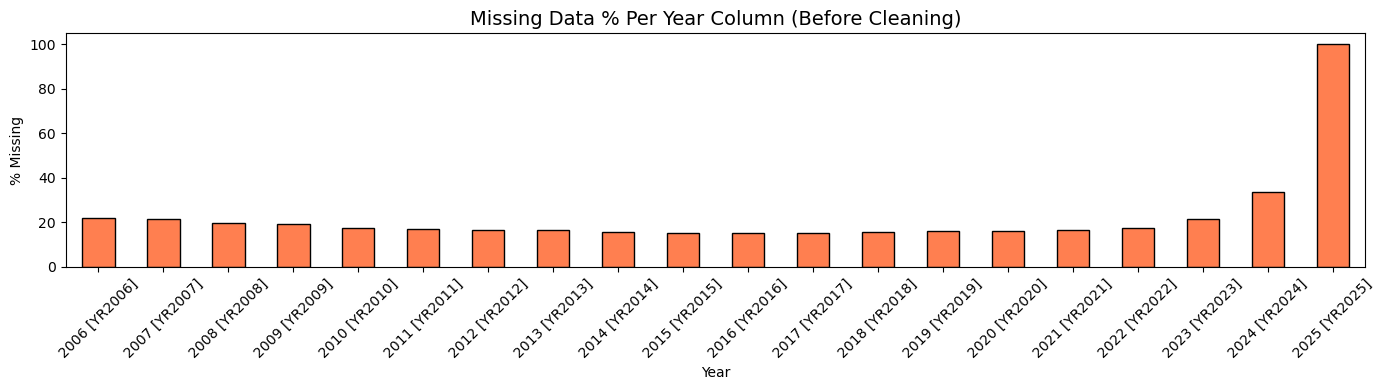


Missing % per year:
2006 [YR2006]     21.8
2007 [YR2007]     21.6
2008 [YR2008]     19.7
2009 [YR2009]     19.4
2010 [YR2010]     17.7
2011 [YR2011]     17.1
2012 [YR2012]     16.8
2013 [YR2013]     16.6
2014 [YR2014]     15.6
2015 [YR2015]     15.0
2016 [YR2016]     15.5
2017 [YR2017]     15.2
2018 [YR2018]     15.6
2019 [YR2019]     16.1
2020 [YR2020]     16.0
2021 [YR2021]     16.6
2022 [YR2022]     17.4
2023 [YR2023]     21.7
2024 [YR2024]     33.8
2025 [YR2025]    100.0
dtype: float64


In [4]:
# ── STEP 4: Visualize Missing Data (Before Cleaning) ─────────────────────────
# Replace '..' with NaN to see true missingness
df_check = df_raw.copy()
year_cols = [c for c in df_check.columns if 'YR' in c]
df_check[year_cols] = df_check[year_cols].replace('..', np.nan).astype(float)

missing_pct = df_check[year_cols].isnull().mean() * 100

plt.figure(figsize=(14, 4))
missing_pct.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Missing Data % Per Year Column (Before Cleaning)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('% Missing')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nMissing % per year:")
print(missing_pct.round(1))

---
## PHASE 3 – Data Preparation

### Strategy
The dataset is in **wide-long mixed format** (one row per country per indicator). We need to:
1. Replace `'..'` with `NaN`
2. **Pivot** the data so each row = one country × one year, with each indicator as a column
3. Drop columns with too many missing values (2024, 2025)
4. Impute remaining missing values
5. Engineer new features (income tier labels for classification)

In [5]:
# ── STEP 5: Replace '..' and Convert to Float ────────────────────────────────
df = df_raw.copy()
year_cols = [c for c in df.columns if 'YR' in c]

# Replace '..' with NaN
df[year_cols] = df[year_cols].replace('..', np.nan)
df[year_cols] = df[year_cols].astype(float)

# Drop rows where Series Name is NaN
df = df.dropna(subset=['Series Name'])

print("Cleaned shape:", df.shape)
print("'..' replaced with NaN and numeric conversion done.")

Cleaned shape: (2660, 24)
'..' replaced with NaN and numeric conversion done.


In [6]:
# ── STEP 6: Drop Sparse Year Columns (2024, 2025) ────────────────────────────
# These years have too many missing values to be useful
cols_to_drop = ['2024 [YR2024]', '2025 [YR2025]']
df = df.drop(columns=cols_to_drop)

year_cols = [c for c in df.columns if 'YR' in c]
print("Year columns kept:", year_cols)
print("Updated shape:", df.shape)

Year columns kept: ['2006 [YR2006]', '2007 [YR2007]', '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]']
Updated shape: (2660, 22)


In [7]:
# ── STEP 7: Pivot – Reshape to Country × Year × Indicator ───────────────────
# Melt to long format first
df_long = df.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name'],
    value_vars=year_cols,
    var_name='Year',
    value_name='Value'
)

# Extract just the year as integer
df_long['Year'] = df_long['Year'].str.extract(r'(\d{4})').astype(int)

# Pivot so each indicator becomes a column
df_pivot = df_long.pivot_table(
    index=['Country Name', 'Country Code', 'Year'],
    columns='Series Name',
    values='Value'
).reset_index()

# Clean up column names
df_pivot.columns.name = None
df_pivot.columns = [
    col.strip().replace(',', '').replace('(', '').replace(')', '').replace('%', 'pct').replace(' ', '_')
    for col in df_pivot.columns
]

print("Pivoted shape:", df_pivot.shape)
print("\nColumn names:")
print(df_pivot.columns.tolist())
df_pivot.head()

Pivoted shape: (4692, 13)

Column names:
['Country_Name', 'Country_Code', 'Year', 'Current_account_balance_pct_of_GDP', 'Foreign_direct_investment_net_inflows_pct_of_GDP', 'GDP_growth_annual_pct', 'GDP_per_capita_current_US$', 'Government_expenditure_on_education_total_pct_of_GDP', 'Gross_capital_formation_pct_of_GDP', 'Gross_domestic_savings_pct_of_GDP', 'Inflation_GDP_deflator_annual_pct', 'Tax_revenue_pct_of_GDP', 'Trade_pct_of_GDP']


,Country_Name,Country_Code,Year,Current_account_balance_pct_of_GDP,Foreign_direct_investment_net_inflows_pct_of_GDP,GDP_growth_annual_pct,GDP_per_capita_current_US$,Government_expenditure_on_education_total_pct_of_GDP,Gross_capital_formation_pct_of_GDP,Gross_domestic_savings_pct_of_GDP,Inflation_GDP_deflator_annual_pct,Tax_revenue_pct_of_GDP,Trade_pct_of_GDP
0,Afghanistan,AFG,2006,NaN,3.413773,5.357403,274.218554,NaN,NaN,NaN,7.199751,6.967598,NaN
1,Afghanistan,AFG,2007,NaN,1.935702,13.826320,376.223152,NaN,NaN,NaN,22.527756,5.283457,NaN
2,Afghanistan,AFG,2008,-2.357990,0.455360,3.924984,381.733238,NaN,NaN,NaN,2.096289,6.087965,NaN
3,Afghanistan,AFG,2009,2.236019,0.451889,21.390528,452.053705,NaN,NaN,NaN,-2.163404,8.481758,NaN
4,Afghanistan,AFG,2010,-3.643314,1.203118,14.362441,560.621505,3.47945,NaN,NaN,3.814630,9.169752,NaN


In [8]:
# ── STEP 8: Rename Columns for Readability ───────────────────────────────────
rename_map = {
    'Current_account_balance_pct_of_GDP': 'current_account_bal',
    'Foreign_direct_investment_net_inflows_pct_of_GDP': 'fdi_inflows',
    'GDP_growth_annual_pct': 'gdp_growth',
    'GDP_per_capita_current_US$': 'gdp_per_capita',
    'Government_expenditure_on_education_total_pct_of_GDP': 'edu_expenditure',
    'Gross_capital_formation_pct_of_GDP': 'capital_formation',
    'Gross_domestic_savings_pct_of_GDP': 'domestic_savings',
    'Inflation_GDP_deflator_annual_pct': 'inflation',
    'Tax_revenue_pct_of_GDP': 'tax_revenue',
    'Trade_pct_of_GDP': 'trade'
}

df_pivot.rename(columns=rename_map, inplace=True)
print("Final columns:", df_pivot.columns.tolist())
df_pivot.head()

Final columns: ['Country_Name', 'Country_Code', 'Year', 'current_account_bal', 'fdi_inflows', 'gdp_growth', 'gdp_per_capita', 'edu_expenditure', 'capital_formation', 'domestic_savings', 'inflation', 'tax_revenue', 'trade']


,Country_Name,Country_Code,Year,current_account_bal,fdi_inflows,gdp_growth,gdp_per_capita,edu_expenditure,capital_formation,domestic_savings,inflation,tax_revenue,trade
0,Afghanistan,AFG,2006,NaN,3.413773,5.357403,274.218554,NaN,NaN,NaN,7.199751,6.967598,NaN
1,Afghanistan,AFG,2007,NaN,1.935702,13.826320,376.223152,NaN,NaN,NaN,22.527756,5.283457,NaN
2,Afghanistan,AFG,2008,-2.357990,0.455360,3.924984,381.733238,NaN,NaN,NaN,2.096289,6.087965,NaN
3,Afghanistan,AFG,2009,2.236019,0.451889,21.390528,452.053705,NaN,NaN,NaN,-2.163404,8.481758,NaN
4,Afghanistan,AFG,2010,-3.643314,1.203118,14.362441,560.621505,3.47945,NaN,NaN,3.814630,9.169752,NaN


Missing % per feature:
tax_revenue            38.5
current_account_bal    29.7
edu_expenditure        27.5
capital_formation      17.8
domestic_savings       17.0
trade                  15.3
fdi_inflows             7.0
inflation               1.7
gdp_growth              1.5
gdp_per_capita          0.7
dtype: float64


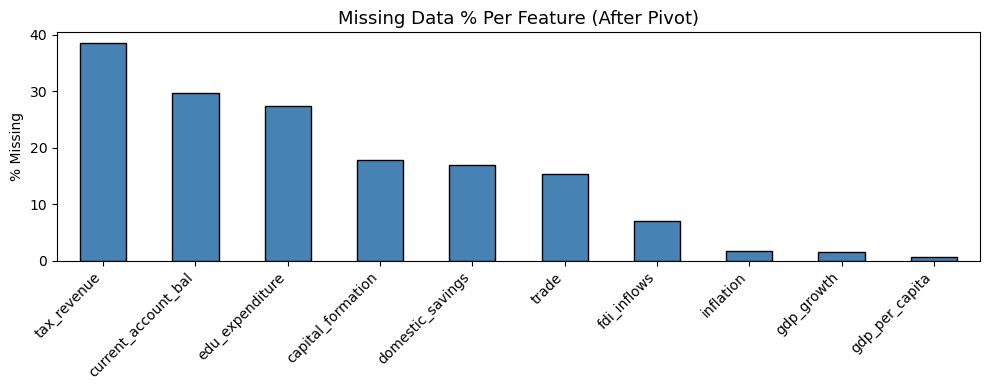

In [9]:
# ── STEP 9: Check Missing Values in Pivoted Dataset ─────────────────────────
feature_cols = ['current_account_bal', 'fdi_inflows', 'gdp_growth', 'gdp_per_capita',
                'edu_expenditure', 'capital_formation', 'domestic_savings',
                'inflation', 'tax_revenue', 'trade']

missing = df_pivot[feature_cols].isnull().mean() * 100
print("Missing % per feature:")
print(missing.round(1).sort_values(ascending=False))

plt.figure(figsize=(10, 4))
missing.sort_values(ascending=False).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Missing Data % Per Feature (After Pivot)', fontsize=13)
plt.ylabel('% Missing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
# ── STEP 10: Impute Missing Values ──────────────────────────────────────────
# Strategy: fill missing values using the median of each feature per country
# This respects each country's own economic pattern

for col in feature_cols:
    df_pivot[col] = df_pivot.groupby('Country_Name')[col].transform(
        lambda x: x.fillna(x.median())
    )

# For any still-missing (countries with ALL nulls for a feature), use global median
for col in feature_cols:
    df_pivot[col].fillna(df_pivot[col].median(), inplace=True)

print("Missing values after imputation:")
print(df_pivot[feature_cols].isnull().sum())
print("\nAll missing values handled!")

Missing values after imputation:
current_account_bal    0
fdi_inflows            0
gdp_growth             0
gdp_per_capita         0
edu_expenditure        0
capital_formation      0
domestic_savings       0
inflation              0
tax_revenue            0
trade                  0
dtype: int64

All missing values handled!


Income Tier Distribution:
income_tier
High            1504
Lower-Middle    1324
Upper-Middle    1259
Low              605
Name: count, dtype: int64


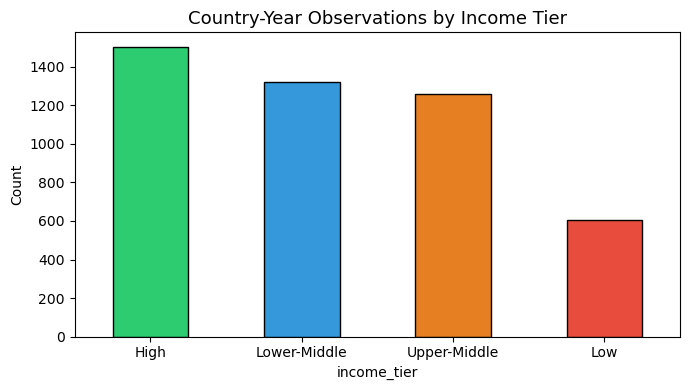

In [11]:
# ── STEP 11: Feature Engineering – Income Tier Labels (for Classification) ──
# We use GDP per capita to create income class labels
# Based loosely on World Bank income classifications

def assign_income_tier(gdp_pc):
    if gdp_pc < 1086:
        return 'Low'
    elif gdp_pc < 4256:
        return 'Lower-Middle'
    elif gdp_pc < 13205:
        return 'Upper-Middle'
    else:
        return 'High'

df_pivot['income_tier'] = df_pivot['gdp_per_capita'].apply(assign_income_tier)

print("Income Tier Distribution:")
print(df_pivot['income_tier'].value_counts())

plt.figure(figsize=(7, 4))
df_pivot['income_tier'].value_counts().plot(kind='bar', color=['#2ecc71','#3498db','#e67e22','#e74c3c'], edgecolor='black')
plt.title('Country-Year Observations by Income Tier', fontsize=13)
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

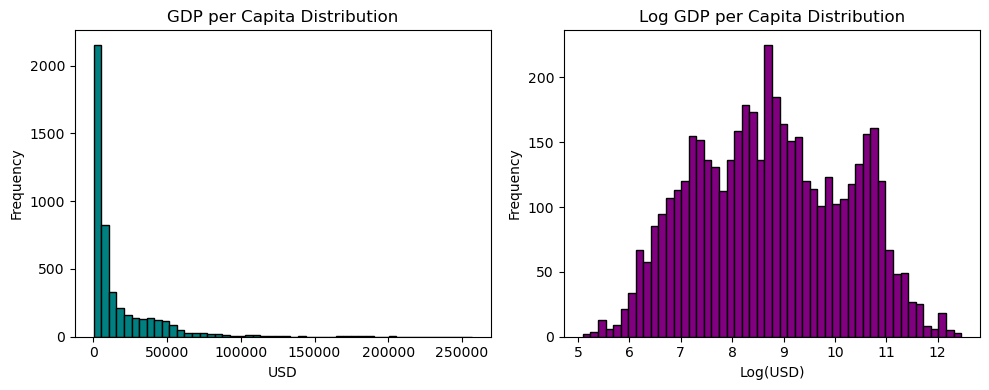

In [12]:
# ── STEP 12: Exploratory Data Analysis (EDA) ────────────────────────────────

# Distribution of GDP per capita
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df_pivot['gdp_per_capita'].plot(kind='hist', bins=50, color='teal', edgecolor='black')
plt.title('GDP per Capita Distribution')
plt.xlabel('USD')

plt.subplot(1, 2, 2)
np.log1p(df_pivot['gdp_per_capita']).plot(kind='hist', bins=50, color='purple', edgecolor='black')
plt.title('Log GDP per Capita Distribution')
plt.xlabel('Log(USD)')

plt.tight_layout()
plt.show()

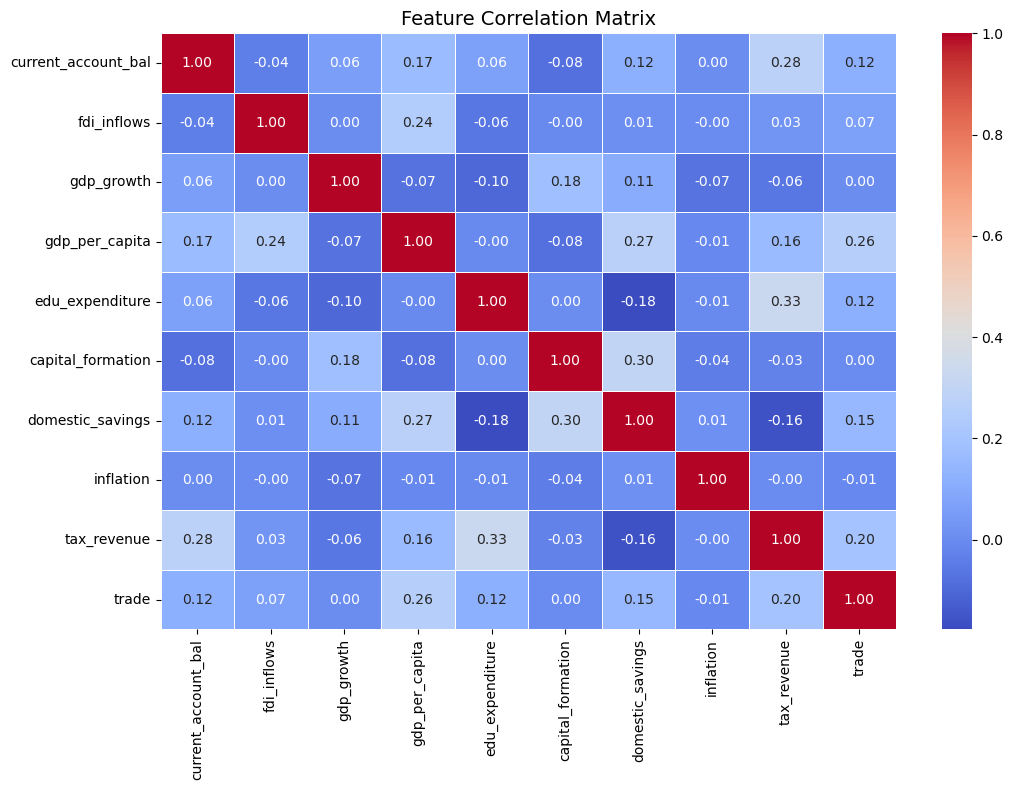

In [13]:
# Correlation heatmap
plt.figure(figsize=(11, 8))
corr = df_pivot[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

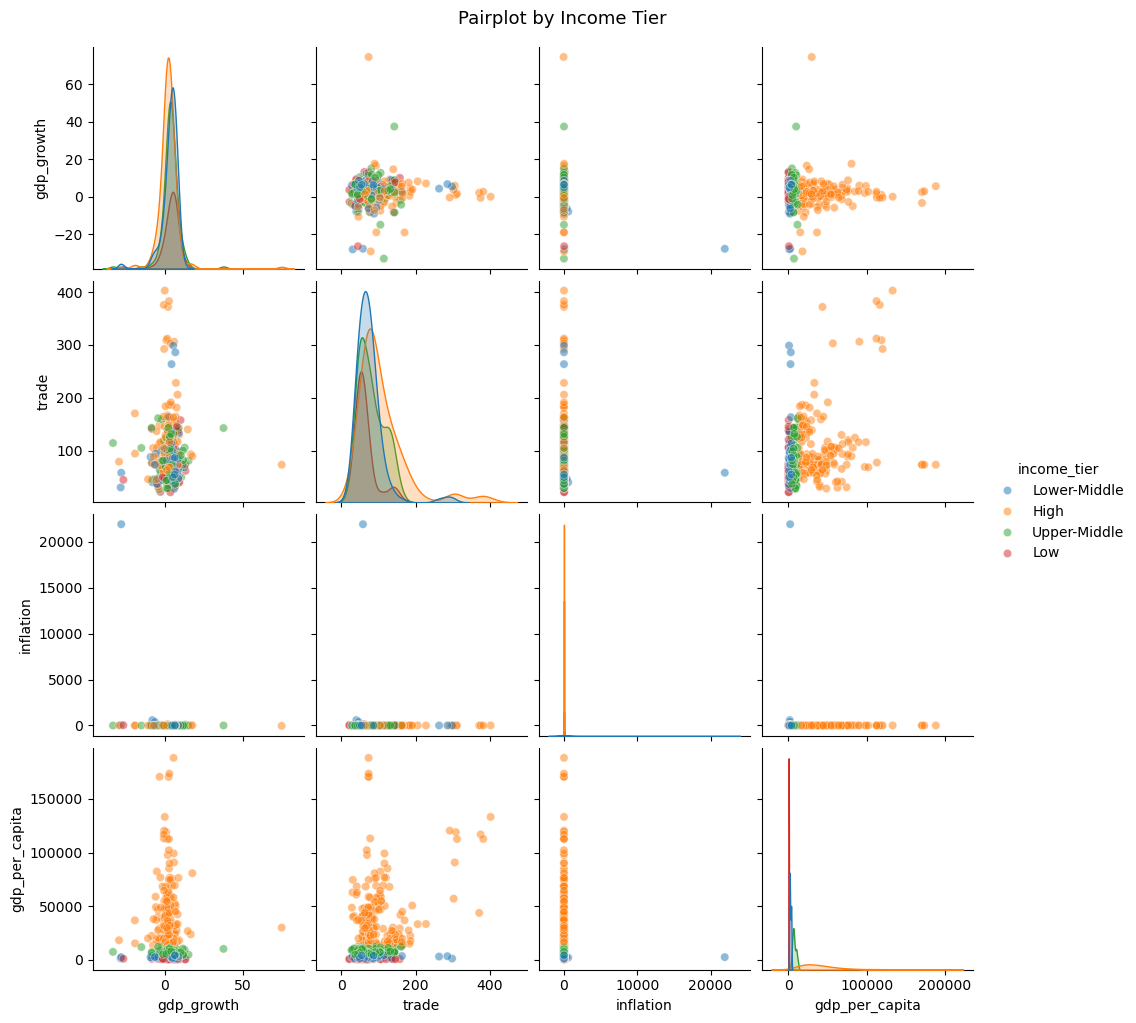

In [14]:
# Pairplot of key features (sampled for speed)
sample_df = df_pivot[feature_cols + ['income_tier']].dropna().sample(500, random_state=42)
sns.pairplot(sample_df, hue='income_tier', vars=['gdp_growth', 'trade', 'inflation', 'gdp_per_capita'],
             plot_kws={'alpha': 0.5}, diag_kind='kde')
plt.suptitle('Pairplot by Income Tier', y=1.02, fontsize=13)
plt.show()

In [15]:
# ── STEP 13: Save Cleaned Dataset ───────────────────────────────────────────
df_pivot.to_csv('GDP_cleaned.csv', index=False)
print("Cleaned dataset saved as 'GDP_cleaned.csv'")
print("Shape:", df_pivot.shape)
df_pivot.describe().round(2)

Cleaned dataset saved as 'GDP_cleaned.csv'
Shape: (4692, 14)


,Year,current_account_bal,fdi_inflows,gdp_growth,gdp_per_capita,edu_expenditure,capital_formation,domestic_savings,inflation,tax_revenue,trade
count,4692.00,4692.00,4692.00,4692.00,4692.00,4692.00,4692.00,4692.00,4692.00,4692.00,4692.00
mean,2014.49,-2.18,8.93,3.13,16485.81,4.30,24.92,21.00,60.23,15.76,85.76
std,5.18,13.18,62.39,5.66,25095.98,1.98,7.74,16.81,3310.42,6.30,54.18
min,2006.00,-60.88,-1303.11,-54.40,161.89,0.00,-15.68,-90.49,-42.92,0.00,2.47
25%,2010.00,-5.62,1.52,1.25,1977.87,3.24,20.93,14.89,1.68,12.72,55.38
50%,2014.00,-2.67,2.78,3.39,6093.31,4.05,24.03,21.57,3.70,15.10,73.31
75%,2019.00,0.23,5.03,5.62,20617.58,5.00,27.92,28.33,7.28,18.10,99.04
max,2023.00,311.75,1709.83,86.83,256799.79,16.39,76.78,87.83,225690.06,147.64,863.20


---
## PHASE 4 – Modeling

### Model 1: Regression – Predict GDP per Capita
**Goal**: Use economic indicators (trade, FDI, inflation, savings, etc.) to predict `gdp_per_capita`.

**Models tried**: Linear Regression, Ridge Regression, Random Forest Regressor

In [16]:
# ── STEP 14: Regression – Prepare Features ──────────────────────────────────
reg_features = ['current_account_bal', 'fdi_inflows', 'edu_expenditure',
                'capital_formation', 'domestic_savings', 'inflation',
                'tax_revenue', 'trade', 'gdp_growth']

target_reg = 'gdp_per_capita'

df_reg = df_pivot[reg_features + [target_reg]].dropna()

X_reg = df_reg[reg_features]
y_reg = df_reg[target_reg]

# Log-transform the target (skewed distribution)
y_reg_log = np.log1p(y_reg)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg_log, test_size=0.2, random_state=42
)

# Scale features
scaler_r = StandardScaler()
X_train_r_sc = scaler_r.fit_transform(X_train_r)
X_test_r_sc  = scaler_r.transform(X_test_r)

print(f"Training samples: {X_train_r.shape[0]}")
print(f"Testing samples:  {X_test_r.shape[0]}")

Training samples: 3753
Testing samples:  939


In [17]:
# ── STEP 15: Train Regression Models ────────────────────────────────────────
results_reg = {}

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train_r_sc, y_train_r)
y_pred_lr = lr.predict(X_test_r_sc)
results_reg['Linear Regression'] = {
    'R2':   r2_score(y_test_r, y_pred_lr),
    'RMSE': np.sqrt(mean_squared_error(y_test_r, y_pred_lr)),
    'MAE':  mean_absolute_error(y_test_r, y_pred_lr)
}

# 2. Ridge Regression (with tuning)
ridge_params = {'alpha': [0.1, 1, 10, 100]}
ridge_cv = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_cv.fit(X_train_r_sc, y_train_r)
best_ridge = ridge_cv.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_r_sc)
results_reg['Ridge Regression'] = {
    'R2':   r2_score(y_test_r, y_pred_ridge),
    'RMSE': np.sqrt(mean_squared_error(y_test_r, y_pred_ridge)),
    'MAE':  mean_absolute_error(y_test_r, y_pred_ridge)
}
print("Best Ridge alpha:", ridge_cv.best_params_)

# 3. Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_r, y_train_r)  # RF doesn't need scaling
y_pred_rf_r = rf_reg.predict(X_test_r)
results_reg['Random Forest'] = {
    'R2':   r2_score(y_test_r, y_pred_rf_r),
    'RMSE': np.sqrt(mean_squared_error(y_test_r, y_pred_rf_r)),
    'MAE':  mean_absolute_error(y_test_r, y_pred_rf_r)
}

print("\n Regression Results (on log-transformed target):")
pd.DataFrame(results_reg).T.round(4)

Best Ridge alpha: {'alpha': 100}

 Regression Results (on log-transformed target):


,R2,RMSE,MAE
Linear Regression,0.3171,1.1884,0.9632
Ridge Regression,0.3190,1.1868,0.9634
Random Forest,0.8263,0.5994,0.4231


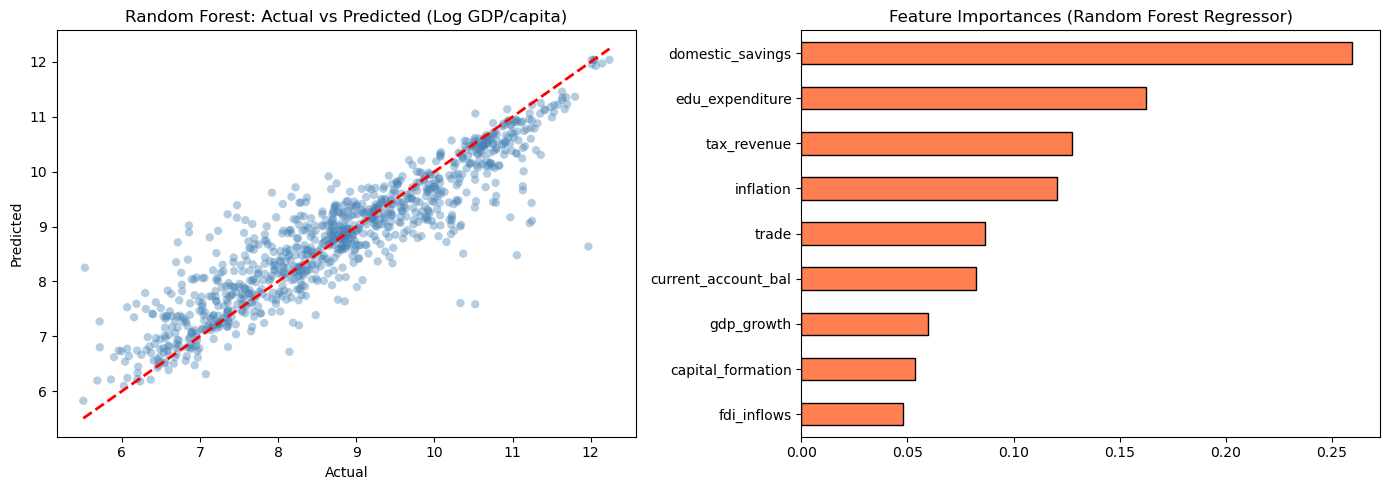

In [18]:
# ── STEP 16: Regression – Feature Importance & Actual vs Predicted ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted (best model: Random Forest)
axes[0].scatter(y_test_r, y_pred_rf_r, alpha=0.4, color='steelblue', edgecolors='none')
axes[0].plot([y_test_r.min(), y_test_r.max()],
             [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
axes[0].set_title('Random Forest: Actual vs Predicted (Log GDP/capita)')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

# Feature Importance
importances = pd.Series(rf_reg.feature_importances_, index=reg_features).sort_values()
importances.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Feature Importances (Random Forest Regressor)')

plt.tight_layout()
plt.show()

---
### Model 2: Classification – Predict Income Tier
**Goal**: Classify each country-year observation into: Low, Lower-Middle, Upper-Middle, High income.

**Models tried**: Decision Tree, Random Forest Classifier, Gradient Boosting

In [19]:
# ── STEP 17: Classification – Prepare Features ──────────────────────────────
clf_features = ['current_account_bal', 'fdi_inflows', 'edu_expenditure',
                'capital_formation', 'domestic_savings', 'inflation',
                'tax_revenue', 'trade', 'gdp_growth']

target_clf = 'income_tier'

df_clf = df_pivot[clf_features + [target_clf]].dropna()

X_clf = df_clf[clf_features]
y_clf = df_clf[target_clf]

le = LabelEncoder()
y_clf_enc = le.fit_transform(y_clf)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf_enc, test_size=0.2, random_state=42, stratify=y_clf_enc
)

scaler_c = StandardScaler()
X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc  = scaler_c.transform(X_test_c)

print("Classes:", le.classes_)
print(f"Train: {X_train_c.shape[0]} | Test: {X_test_c.shape[0]}")

Classes: ['High' 'Low' 'Lower-Middle' 'Upper-Middle']
Train: 3753 | Test: 939


In [20]:
# ── STEP 18: Train Classification Models ────────────────────────────────────
results_clf = {}

# 1. Decision Tree
dt_params = {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10]}
dt_cv = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='accuracy')
dt_cv.fit(X_train_c, y_train_c)
y_pred_dt = dt_cv.best_estimator_.predict(X_test_c)
results_clf['Decision Tree'] = accuracy_score(y_test_c, y_pred_dt)
print("Best DT params:", dt_cv.best_params_)

# 2. Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_c, y_train_c)
y_pred_rf_c = rf_clf.predict(X_test_c)
results_clf['Random Forest'] = accuracy_score(y_test_c, y_pred_rf_c)

# 3. Gradient Boosting
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_clf.fit(X_train_c, y_train_c)
y_pred_gb = gb_clf.predict(X_test_c)
results_clf['Gradient Boosting'] = accuracy_score(y_test_c, y_pred_gb)

print("\n📊 Classification Accuracy:")
for model, acc in results_clf.items():
    print(f"  {model}: {acc:.4f}")

Best DT params: {'max_depth': None, 'min_samples_split': 2}

📊 Classification Accuracy:
  Decision Tree: 0.7146
  Random Forest: 0.8349
  Gradient Boosting: 0.7327


Best Model: Random Forest Classifier

Classification Report:
              precision    recall  f1-score   support

        High       0.85      0.92      0.88       301
         Low       0.87      0.81      0.84       121
Lower-Middle       0.80      0.83      0.82       265
Upper-Middle       0.84      0.75      0.79       252

    accuracy                           0.83       939
   macro avg       0.84      0.83      0.83       939
weighted avg       0.84      0.83      0.83       939



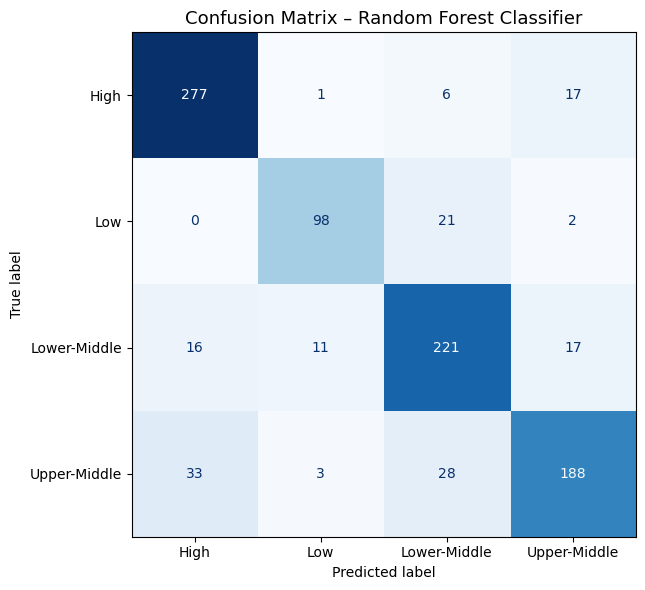

In [21]:
# ── STEP 19: Classification Report & Confusion Matrix ───────────────────────
print("Best Model: Random Forest Classifier")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_rf_c, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_rf_c)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix – Random Forest Classifier', fontsize=13)
plt.tight_layout()
plt.show()

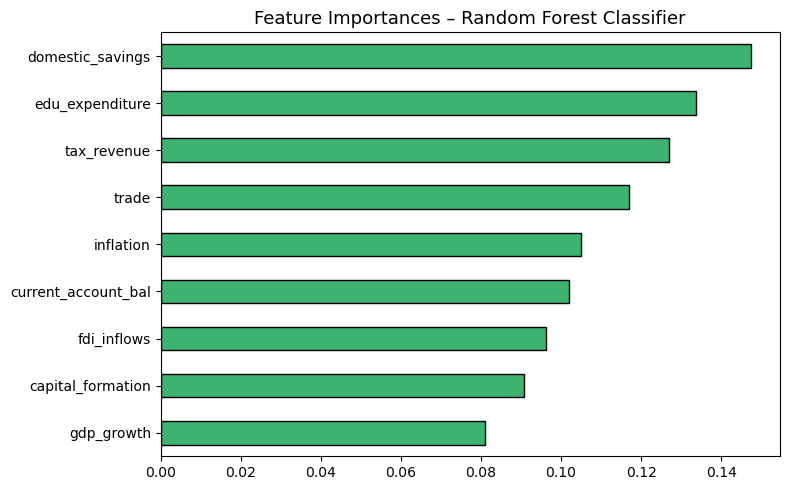

In [22]:
# ── STEP 20: Feature Importance – Classification ────────────────────────────
feat_imp_c = pd.Series(rf_clf.feature_importances_, index=clf_features).sort_values()

plt.figure(figsize=(8, 5))
feat_imp_c.plot(kind='barh', color='mediumseagreen', edgecolor='black')
plt.title('Feature Importances – Random Forest Classifier', fontsize=13)
plt.tight_layout()
plt.show()

---
### Model 3: Time Series – Forecast GDP Growth
**Goal**: For a selected country, use historical GDP growth data (2006–2022) to forecast future GDP growth using ARIMA.

**Countries analyzed**: Canada, India, Brazil (one per group member)

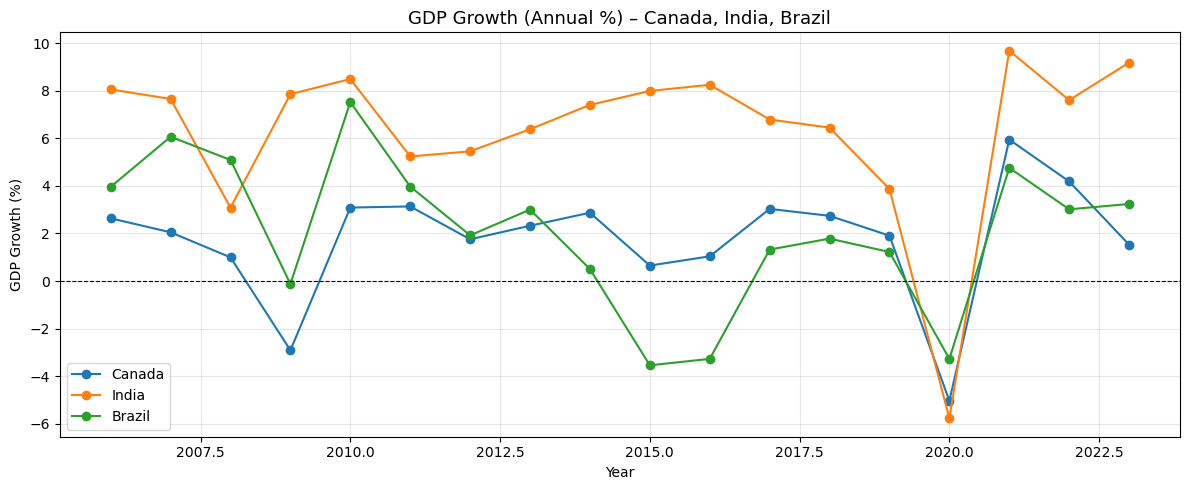

In [23]:
# ── STEP 21: Time Series – Prepare Country-Level GDP Growth Data ─────────────
def get_ts(country_name):
    ts = df_pivot[df_pivot['Country_Name'] == country_name][['Year', 'gdp_growth']]
    ts = ts.sort_values('Year').dropna()
    ts = ts.set_index('Year')
    return ts['gdp_growth']

countries_ts = ['Canada', 'India', 'Brazil']

# Plot GDP growth over time for the 3 countries
plt.figure(figsize=(12, 5))
for country in countries_ts:
    ts = get_ts(country)
    plt.plot(ts.index, ts.values, marker='o', label=country)

plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('GDP Growth (Annual %) – Canada, India, Brazil', fontsize=13)
plt.xlabel('Year')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# ── STEP 22: Stationarity Test (ADF Test) ───────────────────────────────────
# ARIMA requires the series to be stationary

for country in countries_ts:
    ts = get_ts(country)
    result = adfuller(ts.dropna())
    print(f"{country}: ADF Statistic = {result[0]:.3f}, p-value = {result[1]:.4f}", end=" ")
    print("→ Stationary " if result[1] < 0.05 else "→ NOT stationary ")

Canada: ADF Statistic = -3.710, p-value = 0.0040 → Stationary 
India: ADF Statistic = -19.836, p-value = 0.0000 → Stationary 
Brazil: ADF Statistic = -1.273, p-value = 0.6415 → NOT stationary 


Series length: 18 data points → using lags = 8


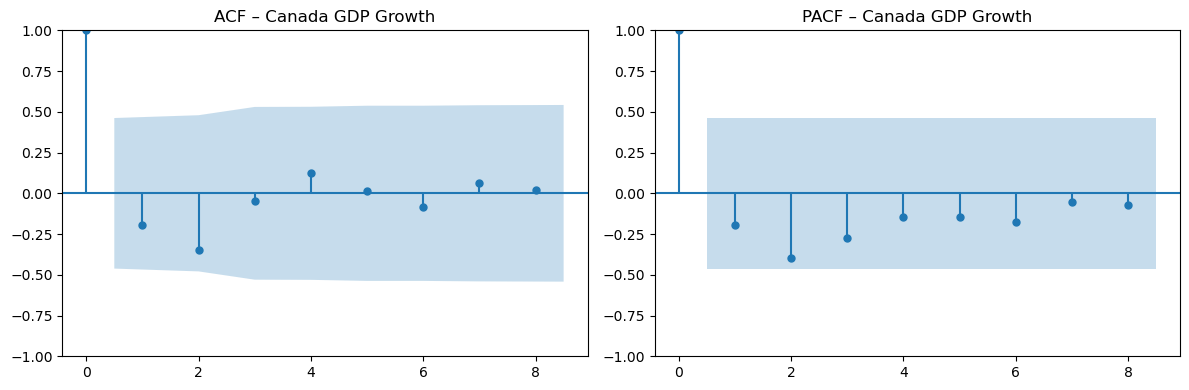

In [25]:
# ── STEP 23: ACF and PACF Plots (for Canada) ────────────────────────────────
ts_canada = get_ts('Canada')
ts_canada_clean = ts_canada.dropna()

# Dynamically set lags to stay within PACF's 50% sample size limit
max_lags = len(ts_canada_clean) // 2 - 1
print(f"Series length: {len(ts_canada_clean)} data points → using lags = {max_lags}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ts_canada_clean, ax=axes[0], lags=max_lags, title='ACF – Canada GDP Growth')
plot_pacf(ts_canada_clean, ax=axes[1], lags=max_lags, title='PACF – Canada GDP Growth')
plt.tight_layout()
plt.show()

# Interpretation note:
# ACF helps choose q (MA order), PACF helps choose p (AR order) for ARIMA(p,d,q)

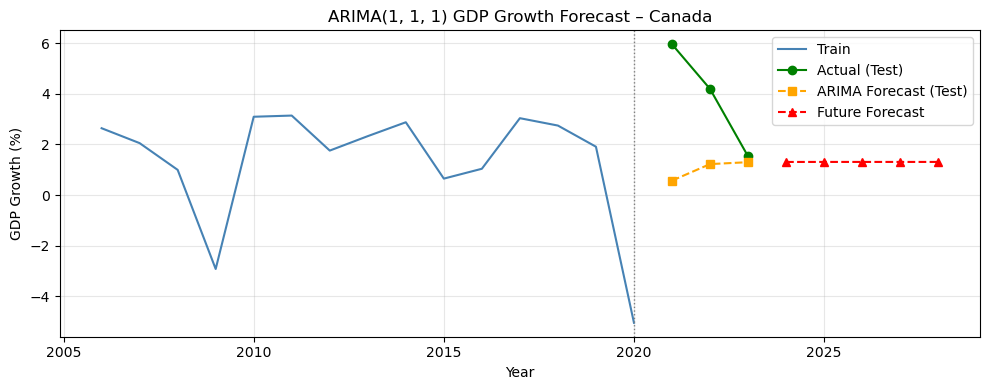

Canada → RMSE: 3.549 | MAE: 2.859


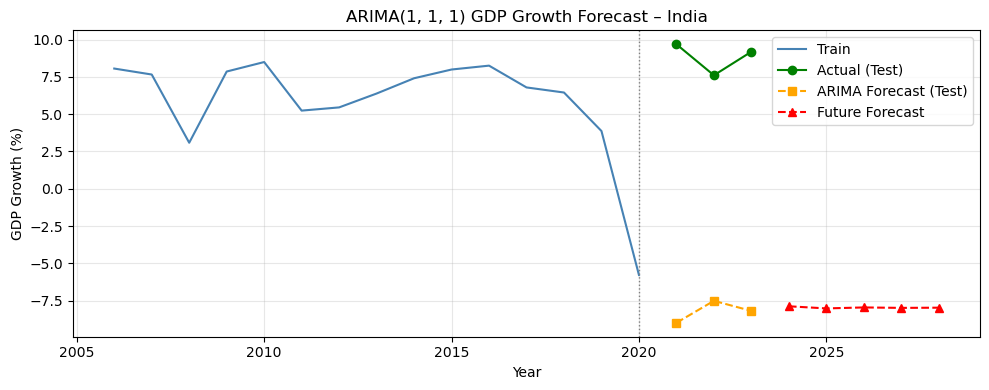

India → RMSE: 17.121 | MAE: 17.058


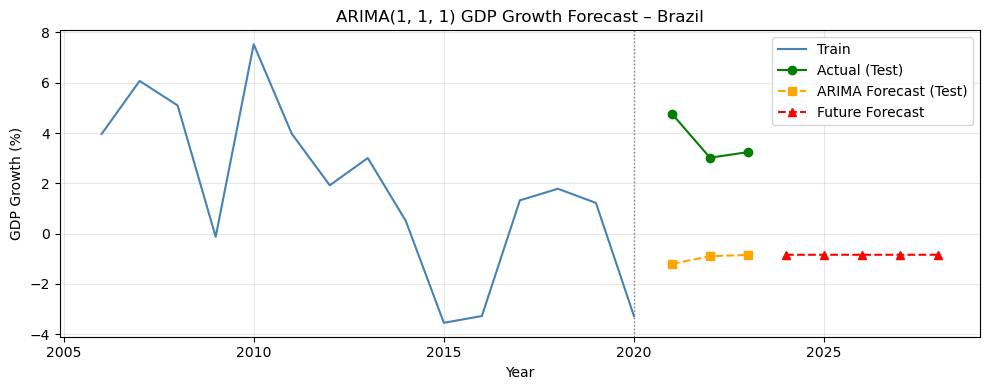

Brazil → RMSE: 4.750 | MAE: 4.658


In [26]:
# ── STEP 24: Fit ARIMA Model for Each Country ────────────────────────────────
def fit_arima_and_forecast(country, order=(1,1,1), steps=5):
    ts = get_ts(country).dropna()
    
    # Convert integer year index to DatetimeIndex (required by ARIMA)
    ts.index = pd.to_datetime(ts.index, format='%Y')
    ts.index.freq = 'YS'  # Annual frequency

    # Train/test split (last 3 years = test)
    train = ts.iloc[:-3]
    test  = ts.iloc[-3:]

    # Fit ARIMA
    model = ARIMA(train, order=order)
    fitted = model.fit()

    # Forecast
    forecast = fitted.forecast(steps=len(test) + steps)
    test_forecast = forecast[:len(test)]
    future_forecast = forecast[len(test):]

    # Metrics on test period
    rmse = np.sqrt(mean_squared_error(test, test_forecast))
    mae  = mean_absolute_error(test, test_forecast)

    # Plot (convert index back to year integers for clean x-axis)
    plt.figure(figsize=(10, 4))
    plt.plot(train.index.year, train.values, label='Train', color='steelblue')
    plt.plot(test.index.year, test.values, label='Actual (Test)', color='green', marker='o')
    plt.plot(test.index.year, test_forecast.values, label='ARIMA Forecast (Test)', color='orange', linestyle='--', marker='s')
    plt.plot(future_forecast.index.year, future_forecast.values, label='Future Forecast', color='red', linestyle='--', marker='^')
    plt.axvline(x=train.index.year[-1], color='gray', linestyle=':', linewidth=1)
    plt.title(f'ARIMA{order} GDP Growth Forecast – {country}')
    plt.xlabel('Year')
    plt.ylabel('GDP Growth (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"{country} → RMSE: {rmse:.3f} | MAE: {mae:.3f}")
    return fitted

# Fit for all 3 countries
model_canada = fit_arima_and_forecast('Canada', order=(1,1,1))
model_india  = fit_arima_and_forecast('India',  order=(1,1,1))
model_brazil = fit_arima_and_forecast('Brazil', order=(1,1,1))

In [27]:
# ── STEP 25: ARIMA Model Summary ────────────────────────────────────────────
print("=== ARIMA Model Summary for Canada ===")
print(model_canada.summary())

=== ARIMA Model Summary for Canada ===
                               SARIMAX Results                                
Dep. Variable:             gdp_growth   No. Observations:                   15
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -33.078
Date:                Fri, 20 Mar 2026   AIC                             72.155
Time:                        19:44:06   BIC                             74.073
Sample:                    01-01-2006   HQIC                            71.978
                         - 01-01-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1162      0.712      0.163      0.870      -1.278       1.511
ma.L1         -0.9990    199.861     -0.005      0.996    -392.719     390.721
sigma2       

---
## PHASE 5 – Evaluation

### Summary of Results

In [28]:
# ── STEP 26: Evaluation Summary Table ───────────────────────────────────────
print("=" * 60)
print("REGRESSION RESULTS (predicting log GDP per capita)")
print("=" * 60)
reg_df = pd.DataFrame(results_reg).T
print(reg_df.round(4))

print("\n" + "=" * 60)
print("CLASSIFICATION RESULTS (predicting income tier)")
print("=" * 60)
for model, acc in results_clf.items():
    print(f"  {model}: Accuracy = {acc:.4f}")

print("\n" + "=" * 60)
print("TIME SERIES NOTE")
print("=" * 60)
print("  ARIMA(1,1,1) fitted for Canada, India, Brazil.")
print("  See Step 24 outputs for RMSE and MAE per country.")

REGRESSION RESULTS (predicting log GDP per capita)
                       R2    RMSE     MAE
Linear Regression  0.3171  1.1884  0.9632
Ridge Regression   0.3190  1.1868  0.9634
Random Forest      0.8263  0.5994  0.4231

CLASSIFICATION RESULTS (predicting income tier)
  Decision Tree: Accuracy = 0.7146
  Random Forest: Accuracy = 0.8349
  Gradient Boosting: Accuracy = 0.7327

TIME SERIES NOTE
  ARIMA(1,1,1) fitted for Canada, India, Brazil.
  See Step 24 outputs for RMSE and MAE per country.


In [29]:
# ── STEP 27: Cross-Validation for Best Models ────────────────────────────────
# CV for regression
cv_scores_reg = cross_val_score(rf_reg, X_reg, y_reg_log, cv=5, scoring='r2')
print(f"Random Forest Regressor – CV R² scores: {cv_scores_reg.round(3)}")
print(f"  Mean R²: {cv_scores_reg.mean():.4f} ± {cv_scores_reg.std():.4f}")

print()

# CV for classification
cv_scores_clf = cross_val_score(rf_clf, X_clf, y_clf_enc, cv=5, scoring='accuracy')
print(f"Random Forest Classifier – CV Accuracy: {cv_scores_clf.round(3)}")
print(f"  Mean Accuracy: {cv_scores_clf.mean():.4f} ± {cv_scores_clf.std():.4f}")

Random Forest Regressor – CV R² scores: [0.377 0.416 0.535 0.459 0.524]
  Mean R²: 0.4620 ± 0.0609

Random Forest Classifier – CV Accuracy: [0.497 0.577 0.575 0.548 0.551]
  Mean Accuracy: 0.5497 ± 0.0287


---
## PHASE 6 – Deployment / Reflection

### How Could These Models Be Applied?

1. **Regression Model**: Could be embedded in a World Bank or IMF dashboard to estimate GDP per capita for countries with incomplete reporting, using available indicator data as inputs.

2. **Classification Model**: Could assist development organizations in automatically tagging countries into funding tiers to streamline aid allocation processes.

3. **Time Series Forecasts**: Could support central bank economists and finance ministers in early-stage GDP growth projections for budget planning.

### Limitations
- Many countries had significant missing data, especially for education expenditure and tax revenue in recent years.
- ARIMA is a univariate model — it only uses past GDP growth to predict future values. A multivariate model (e.g., VAR or SARIMAX with exogenous inputs) would be more powerful.
- Income tier labels were derived from the data itself (GDP per capita), which creates a data leakage risk for classification. A future approach would use external pre-labeled data.
- 2024 and 2025 data was largely unavailable and had to be dropped.

### Suggestions for Future Improvement
- Use SARIMAX for time series to incorporate seasonality and external regressors.
- Apply XGBoost or LightGBM for regression and classification — likely to outperform Random Forest.
- Collect real World Bank income classification labels to avoid leakage in classification.
- Expand features by merging with population, health, or governance datasets.